# Coherent pullback branches for the Böttcher coordinate

This notebook visualizes the geometric obstruction behind the remaining Lean target

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

For $f(z)=z^2+2$, the near-infinity coordinate $\Phi_\infty$ is already constructed in Lean as `MLC.logSeriesBottcherApprox`. For a basin point $z$, a basin extension should be defined by choosing $N$ such that $f^N(z)$ is near infinity and setting

$$
\Phi(z) = \left(\Phi_\infty(f^N(z))\right)^{1/2^N}.
$$

The missing issue is not the formula; it is the **branch choice**. The equation $w^{2^N}=\Phi_\infty(f^N(z))$ has $2^N$ roots. The root chosen at time $N$ must agree with the root chosen at time $N+1$, and must vary holomorphically in $z$. A naive principal root generally does not supply that coherence.

## What “pullback” means here

Near infinity we already have a coordinate $
\Phi_\infty
$ satisfying the Böttcher equation

$$
\Phi_\infty(f(z))=\Phi_\infty(z)^2.
$$

If a basin point $z$ is not yet near infinity, choose an escape time $N$ such that $f^N(z)$ is in the near-infinity region. Then $\Phi_\infty(f^N(z))$ is known. To recover a possible value of $\Phi(z)$, solve

$$
w^{2^N}=\Phi_\infty(f^N(z)).
$$

This backwards recovery is the “pullback”: we pull the known near-infinity coordinate value back through $N$ iterates of the squaring map. Algebraically there are $2^N$ possible roots. A coherent basin coordinate must choose one root at each level so that the choice at level $N+1$ agrees with the choice at level $N$, and so that the choice varies holomorphically with $z$.

The naive principal-root pullback means: at every level, take the principal complex root. The problem is that principal roots use a fixed branch cut, so the principal choice at level $N+1$ need not be compatible with the principal choice at level $N$.

In [1]:
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt

c = 2.0 + 0.0j

def f(z):
    return z*z + c

def iterate(z, n):
    for _ in range(n):
        z = f(z)
    return z

def escape_time(z, R=4.0, max_iter=30):
    w = z
    for n in range(max_iter + 1):
        if abs(w) > R:
            return n
        w = f(w)
    return None

def principal_root(w, degree):
    return cmath.exp(cmath.log(w) / degree)

def all_roots(w, degree):
    r = abs(w) ** (1 / degree)
    theta = cmath.phase(w)
    return np.array([r * cmath.exp(1j * (theta + 2 * math.pi * k) / degree) for k in range(degree)])

## A finite near-infinity approximation

The Lean coordinate is represented by a logarithmic correction series. For visualization, use the finite approximation

$$
\Phi_M(z)=z\exp\left(\sum_{n=0}^{M-1}2^{-(n+1)}\log\left(1+\frac{2}{f^n(z)^2}\right)\right).
$$

This is only for visualization; the Lean development proves the corresponding convergence/near-infinity package exactly.

In [2]:
def phi_inf_approx(z, terms=40):
    s = 0.0 + 0.0j
    w = z
    for n in range(terms):
        s += (0.5 ** (n + 1)) * cmath.log(1 + c / (w*w))
        w = f(w)
        if abs(w) > 1e80:
            break
    return z * cmath.exp(s)

def pullback_candidate(z, N, terms=40):
    W = phi_inf_approx(iterate(z, N), terms=terms)
    return principal_root(W, 2**N)

## Root choices at one basin point

At escape time $N$, the equation $w^{2^N}=\Phi_\infty(f^N(z))$ has $2^N$ possible roots. The principal root is just one arbitrary branch. The coherent branch is the one compatible with nearby points and with later escape times.

escape time for z0 = 2 f^N(z0)= (6+0j)


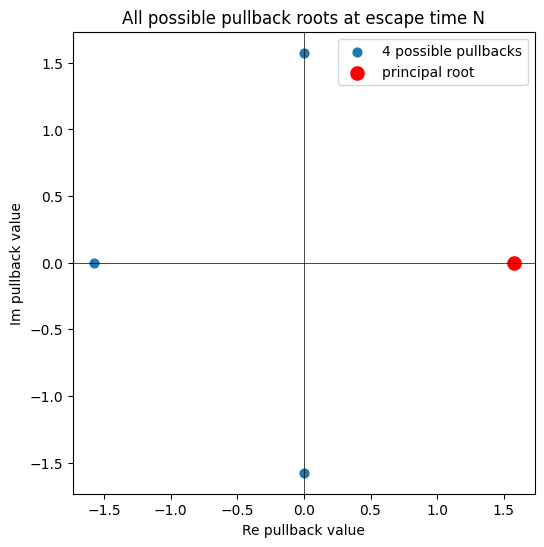

In [3]:
z0 = 0.0 + 0.0j
N = escape_time(z0, R=4.0, max_iter=10)
print('escape time for z0 =', N, 'f^N(z0)=', iterate(z0, N))

W = phi_inf_approx(iterate(z0, N), terms=50)
roots = all_roots(W, 2**N)
principal = principal_root(W, 2**N)

plt.figure(figsize=(6, 6))
plt.scatter(roots.real, roots.imag, s=40, label=f'{2**N} possible pullbacks')
plt.scatter([principal.real], [principal.imag], color='red', s=90, label='principal root')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('All possible pullback roots at escape time N')
plt.xlabel('Re pullback value')
plt.ylabel('Im pullback value')
plt.legend()
plt.show()

## A concrete branch decision

For a fixed point $z_0$, suppose $N$ is the first time such that $f^N(z_0)$ is near infinity.

1. Compute all $2^N$ candidates for $\Phi(z_0)$ from $\Phi_\infty(f^N(z_0))$.
2. Pick one candidate at level $N$; below we use the principal root and mark it red.
3. At level $N+1$, compute all $2^{N+1}$ candidates from $\Phi_\infty(f^{N+1}(z_0))$.
4. The coherent choice at level $N+1$ is the root closest to the previous selected value, not necessarily the principal root at level $N+1$.

This “closest root” rule is only a visualization of local continuation. The proof needs a theorem that this continuation is well-defined and holomorphic on neighborhoods, not just for one point.

z0 = 0j
escape time N = 2
f^N(z0) = (6+0j)
chosen root at N          = 1.5758342+0j
principal root at N+1     = 1.5758342+0j
coherent choice at N+1    = 1.5758342+0j
distance principal N+1    = 2.22e-16
distance coherent N+1     = 2.22e-16


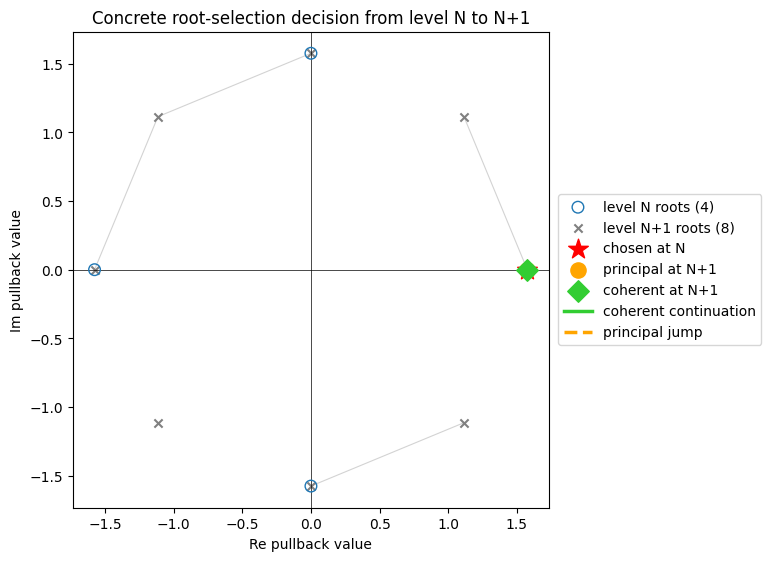

In [4]:
z0 = 0.0 + 0.0j
N = escape_time(z0, R=4.0, max_iter=10)
W_N = phi_inf_approx(iterate(z0, N), terms=60)
W_N1 = phi_inf_approx(iterate(z0, N + 1), terms=60)

roots_N = all_roots(W_N, 2**N)
roots_N1 = all_roots(W_N1, 2**(N + 1))

chosen_N = principal_root(W_N, 2**N)
principal_N1 = principal_root(W_N1, 2**(N + 1))
compatible_N1 = roots_N1[np.argmin(np.abs(roots_N1 - chosen_N))]

# For each level-N root, show the two closest level-(N+1) roots. This visualizes
# the refinement relation: passing from N to N+1 doubles the root choices.
connections = []
for r in roots_N:
    child_indices = np.argsort(np.abs(roots_N1 - r))[:2]
    for idx in child_indices:
        connections.append((r, roots_N1[idx]))

print(f"z0 = {z0}")
print(f"escape time N = {N}")
print(f"f^N(z0) = {iterate(z0, N)}")
print(f"chosen root at N          = {chosen_N:.8g}")
print(f"principal root at N+1     = {principal_N1:.8g}")
print(f"coherent choice at N+1    = {compatible_N1:.8g}")
print(f"distance principal N+1    = {abs(principal_N1 - chosen_N):.4g}")
print(f"distance coherent N+1     = {abs(compatible_N1 - chosen_N):.4g}")

fig, ax = plt.subplots(figsize=(8.5, 7))
for parent, child in connections:
    ax.plot([parent.real, child.real], [parent.imag, child.imag], color='lightgray', linewidth=0.8, zorder=1)

ax.scatter(roots_N.real, roots_N.imag, s=70, facecolors='none', edgecolors='tab:blue', label=f'level N roots ({2**N})', zorder=3)
ax.scatter(roots_N1.real, roots_N1.imag, s=35, marker='x', color='gray', label=f'level N+1 roots ({2**(N+1)})', zorder=2)
ax.scatter([chosen_N.real], [chosen_N.imag], color='red', marker='*', s=220, label='chosen at N', zorder=5)
ax.scatter([principal_N1.real], [principal_N1.imag], color='orange', marker='o', s=120, label='principal at N+1', zorder=5)
ax.scatter([compatible_N1.real], [compatible_N1.imag], color='limegreen', marker='D', s=120, label='coherent at N+1', zorder=5)
ax.plot([chosen_N.real, compatible_N1.real], [chosen_N.imag, compatible_N1.imag], color='limegreen', linewidth=2.5, label='coherent continuation', zorder=4)
ax.plot([chosen_N.real, principal_N1.real], [chosen_N.imag, principal_N1.imag], color='orange', linestyle='--', linewidth=2.5, label='principal jump', zorder=4)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Concrete root-selection decision from level N to N+1')
ax.set_xlabel('Re pullback value')
ax.set_ylabel('Im pullback value')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
fig.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

## Comparing escape time $N$ and $N+1$

If the branch choices are coherent, pulling back from $N$ and from $N+1$ should give the same value.

At level $N$, we solve

$$
w^{2^N}=\Phi_\infty(f^N(z)).
$$

At level $N+1$, we solve

$$
w^{2^{N+1}}=\Phi_\infty(f^{N+1}(z)).
$$

Because the near-infinity coordinate satisfies

$$
\Phi_\infty(f^{N+1}(z))=\Phi_\infty(f^N(z))^2,
$$

every level-$N$ solution should have two level-$(N+1)$ descendants whose squares are compatible with it. Geometrically, the level-$N$ roots form a polygon of possible values, while the level-$(N+1)$ roots refine this polygon by doubling the number of points.

The heatmap below measures what goes wrong if we use the naive principal-root rule independently at every escape time. For each point $z$, it compares:

1. the principal pullback from the first escape time $N$;
2. the principal pullback from the next time $N+1$.

The color is the phase mismatch between these two values. Dark regions mean the two choices nearly agree. Bright regions mean the principal branch has jumped to a different root.

This is the unresolved formal problem: algebraically all roots exist, but Lean needs a theorem selecting roots coherently as $z$ varies and as the escape time changes. The principal-root function has a branch cut, so it can make locally inconsistent choices. A valid Böttcher basin extension must prove that the chosen branch is independent of $N$ and locally holomorphic on the basin.

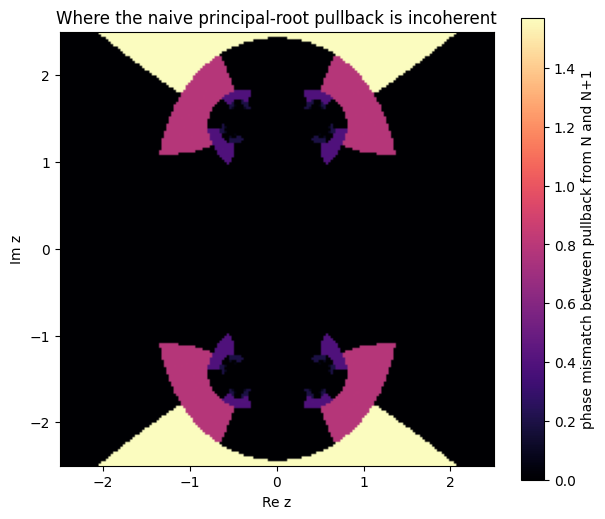

In [5]:
def phase_error_between_N_and_N1(z, N, terms=40):
    a = pullback_candidate(z, N, terms=terms)
    b = pullback_candidate(z, N + 1, terms=terms)
    if abs(a) == 0 or abs(b) == 0:
        return np.nan
    return abs(cmath.phase(a / b))

xs = np.linspace(-2.5, 2.5, 180)
ys = np.linspace(-2.5, 2.5, 180)
Z = np.empty((len(ys), len(xs)))

for j, y in enumerate(ys):
    for i, x in enumerate(xs):
        z = x + 1j*y
        N = escape_time(z, R=4.0, max_iter=8)
        if N is None or N >= 8:
            Z[j, i] = np.nan
        else:
            Z[j, i] = phase_error_between_N_and_N1(z, N, terms=30)

plt.figure(figsize=(7, 6))
im = plt.imshow(Z, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin='lower', cmap='magma')
plt.colorbar(im, label='phase mismatch between pullback from N and N+1')
plt.title('Where the naive principal-root pullback is incoherent')
plt.xlabel('Re z')
plt.ylabel('Im z')
plt.show()

## Formal meaning of “selected coherently”

Let $\Phi_\infty$ be the already-constructed near-infinity coordinate on an outside region $V$. For a basin point $z$, choose any escape iterate $N$ such that

$$
f^N(z)\in V.
$$

A pullback value is any solution of

$$
W_N(z)^{2^N}=\Phi_\infty(f^N(z)).
$$

Saying that the roots are **selected coherently** means more than choosing one root from this finite set. Formally, the desired basin coordinate $\Phi$ must satisfy the following conditions.

### 1. Escape-iterate independence

If $N$ and $M$ are two escape times for the same point $z$, then the pullback construction gives the same value:

$$
W_N(z)=W_M(z).
$$

Equivalently, once $\Phi(z)$ is chosen, it must satisfy

$$
\Phi(z)^{2^N}=\Phi_\infty(f^N(z))
$$

for every sufficiently large escape time $N$, not just for the first chosen one.

This is the first missing theorem behind `PrincipalPullbackCoherentDataFor`.

### 2. Compatibility between consecutive escape times

For every escape time $N$, the value chosen at time $N+1$ must be the same as the value chosen at time $N$:

$$
W_{N+1}(z)=W_N(z).
$$

Using the Böttcher equation near infinity,

$$
\Phi_\infty(f^{N+1}(z))=\Phi_\infty(f^N(z))^2,
$$

this says that the chosen $2^{N+1}$-root must be the descendant of the chosen $2^N$-root, not an unrelated root selected by the principal branch.

### 3. Local holomorphic branch choice

For every basin point $z_0$, there must be a neighborhood $U$ of $z_0$ and a holomorphic function

$$
\Phi_U:U\to\mathbb C
$$

such that for all $z\in U$ and all sufficiently large escape times $N$,

$$
\Phi_U(z)^{2^N}=\Phi_\infty(f^N(z)).
$$

This prevents the branch from jumping when $z$ moves slightly. Pointwise root choices are not enough; the chosen root must vary holomorphically.

### 4. Compatibility on overlaps

If two neighborhoods $U$ and $U'$ overlap, their local branches must agree on $U\cap U'$:

$$
\Phi_U=\Phi_{U'} \quad \text{on } U\cap U'.
$$

This gives a single global holomorphic basin coordinate, rather than unrelated local choices.

### Lean target

The current Lean seam packages the consequences of these coherence facts as

```lean
+Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

The notebook pictures show why the first two conditions are nontrivial: the principal-root rule can choose different descendants at levels $N$ and $N+1$. The formal proof must replace that naive rule by a coherent holomorphic branch selection.

## What the Lean proof still needs

The formal target `PrincipalPullbackCoherentDataFor (2 : ℂ)` needs a theorem saying that the chosen pullback branches:

1. do not depend on which escape iterate is used;
2. vary holomorphically on neighborhoods in the basin;
3. preserve semiconjugacy $\Phi(f(z))=\Phi(z)^2$;
4. give the correct modulus $|\Phi(z)|=e^{G(z)}$.

The plots above show why this is a branch-coherence theorem, not just an algebraic identity. Algebraically, roots exist. Geometrically and analytically, the roots must be selected coherently along orbits and across neighborhoods.